In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os
import plotly.express as px

In [13]:
df = pd.read_csv(r'../merge/raw/csv_full.csv', sep=';')
df_model = df.copy()

In [14]:
# Valeurs nulles
null_counts = df_model.isnull().sum()
null_pct = (null_counts / len(df_model) * 100).round(2)

pd.DataFrame({
    'null_count': null_counts,
    'null_%': null_pct
}).sort_values('null_%', ascending=False)

,null_count,null_%
taux_plein_teom,54845,56.45
taux_global_th,49879,51.34
taux_global_tfb,49879,51.34
taux_global_tfnb,49879,51.34
prix_m2,5033,5.18
zone_emploi,142,0.15
population,7,0.01
code_postal,7,0.01
dep_code,7,0.01
nom_commune,7,0.01


In [15]:
print(f"Doublons totaux : {df_model.duplicated().sum()}")

Doublons totaux : 0


In [16]:
df_model.columns

Index(['annee', 'code_commune', 'prix_m2', 'nom_commune', 'dep_code',
       'dep_nom', 'reg_code', 'reg_nom', 'code_postal', 'population',
       'densite', 'superficie_km2', 'zone_emploi', 'taux_global_tfb',
       'taux_global_tfnb', 'taux_plein_teom', 'taux_global_th', 'y'],
      dtype='str')

In [17]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 97158 entries, 0 to 97157
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   annee             97158 non-null  int64  
 1   code_commune      97158 non-null  int64  
 2   prix_m2           92125 non-null  float64
 3   nom_commune       97151 non-null  str    
 4   dep_code          97151 non-null  float64
 5   dep_nom           97151 non-null  str    
 6   reg_code          97151 non-null  float64
 7   reg_nom           97151 non-null  str    
 8   code_postal       97151 non-null  float64
 9   population        97151 non-null  float64
 10  densite           97151 non-null  float64
 11  superficie_km2    97151 non-null  float64
 12  zone_emploi       97016 non-null  float64
 13  taux_global_tfb   47279 non-null  float64
 14  taux_global_tfnb  47279 non-null  float64
 15  taux_plein_teom   42313 non-null  float64
 16  taux_global_th    47279 non-null  float64
 17  y   

In [18]:
df_model = df_model.drop(columns=['nom_commune', 'dep_nom', 'reg_nom','prix_m2'])
print(df_model.columns.tolist())

['annee', 'code_commune', 'dep_code', 'reg_code', 'code_postal', 'population', 'densite', 'superficie_km2', 'zone_emploi', 'taux_global_tfb', 'taux_global_tfnb', 'taux_plein_teom', 'taux_global_th', 'y']


In [19]:
df_model.columns

Index(['annee', 'code_commune', 'dep_code', 'reg_code', 'code_postal',
       'population', 'densite', 'superficie_km2', 'zone_emploi',
       'taux_global_tfb', 'taux_global_tfnb', 'taux_plein_teom',
       'taux_global_th', 'y'],
      dtype='str')

In [20]:
features = ['annee', 'code_commune', 'dep_code', 'reg_code', 'code_postal',
       'population', 'densite', 'superficie_km2', 'zone_emploi']

X = df_model[features]
y = df_model['y']

# Split par année
train = df_model[df_model['annee'] < 2024]
test  = df_model[df_model['annee'] == 2024]

X_train = train[features]
y_train = train['y']
X_test  = test[features]
y_test  = test['y']

print(f"Train : {len(X_train)} lignes")
print(f"Test  : {len(X_test)} lignes")
print(f"\nDistribution train :\n{y_train.value_counts()}")
print(f"\nDistribution test :\n{y_test.value_counts()}")

Train : 64892 lignes
Test  : 32266 lignes

Distribution train :
y
stable    35401
baisse    15307
hausse    14184
Name: count, dtype: int64

Distribution test :
y
baisse    15487
hausse    13517
stable     3262
Name: count, dtype: int64


In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Modèle entraîné ✓")
print(f"Nombre d'arbres : {rf.n_estimators}")
print(f"Classes : {rf.classes_}")

Modèle entraîné ✓
Nombre d'arbres : 100
Classes : ['baisse' 'hausse' 'stable']


              precision    recall  f1-score   support

      baisse       0.36      0.36      0.36     15487
      hausse       0.28      0.29      0.29     13517
      stable       0.71      0.62      0.66      3262

    accuracy                           0.36     32266
   macro avg       0.45      0.42      0.44     32266
weighted avg       0.36      0.36      0.36     32266



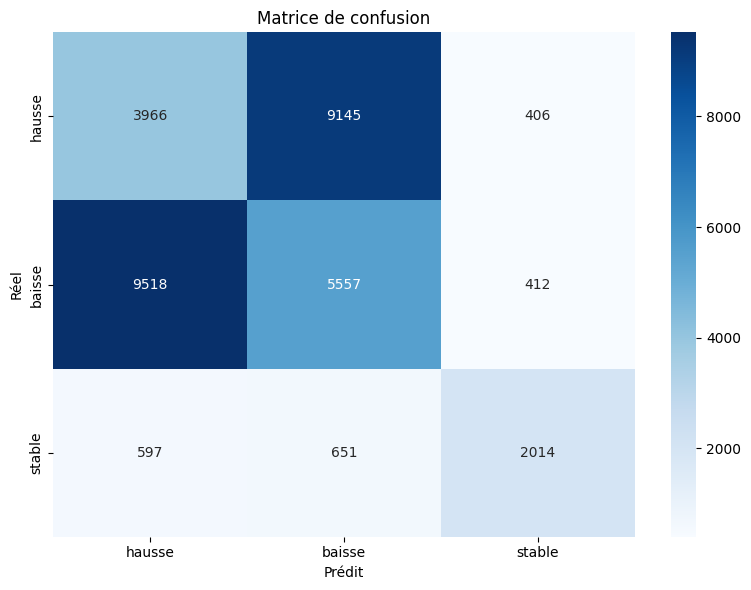

In [23]:
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred, labels=['hausse', 'baisse', 'stable'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=['hausse', 'baisse', 'stable'],
            yticklabels=['hausse', 'baisse', 'stable'],
            cmap='Blues')
plt.title('Matrice de confusion')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()